# Ganga River Water Quality Classification using Random 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Load Data
Load the raw water quality monitoring dataset from `Datasets/stations_full.csv`.

In [2]:
# --- 1. Load Data ---
df = pd.read_csv('Datasets/cleaned_stations.csv', skiprows=[1])
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (1425, 36)


,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg,wqi_category
0,31.0,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,...,96.5,1.8,1.9,1.55,1.095,1490.0,855.0,680.0,1260.0,Poor
1,31.0,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,...,87.5,1.8,1.9,0.76,0.700,1490.0,855.0,1250.0,975.0,Poor
2,31.0,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,...,94.5,0.0,1.0,1.42,1.030,88.0,66.0,461.0,309.5,Poor
3,31.0,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,...,82.0,0.0,1.0,0.65,0.645,97.0,71.5,320.0,270.0,Poor
4,31.0,4.0,16.0,7.6,8.7,6.7,7.8,44.0,128.0,1.0,...,86.0,0.0,1.0,0.58,0.610,171.0,134.5,680.0,580.0,Poor


## 2. Data Overview
Inspect summary information, data types, and descriptive statistics.

In [3]:
# View DataFrame summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state_name              1425 non-null   float64
 1   temp_min                1425 non-null   float64
 2   temp_max                1425 non-null   float64
 3   do_min                  1425 non-null   float64
 4   do_max                  1425 non-null   float64
 5   ph_min                  1425 non-null   float64
 6   ph_max                  1425 non-null   float64
 7   conductivity_min        1425 non-null   float64
 8   conductivity_max        1425 non-null   float64
 9   bod_min                 1425 non-null   float64
 10  bod_max                 1425 non-null   float64
 11  nitrate_min             1425 non-null   float64
 12  nitrate_max             1425 non-null   float64
 13  fecal_coliform_min      1425 non-null   float64
 14  fecal_coliform_max      1425 non-null   float64
 15

In [4]:
# View numerical column statistics
df.describe()

,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_range,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg
count,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,...,1425.000000,1425.000000,1425.000000,1425.000000,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03
mean,53.369825,20.019228,27.318877,5.876912,7.913544,13.167944,21.911495,307.402175,1275.803509,2.612189,...,968.401333,791.602842,2.866400,4.045389,1.419247e+04,7.490358e+03,7.482804e+04,4.143025e+04,3.594050e+05,1.864064e+05
std,24.674227,55.831321,6.103040,2.090816,1.934334,45.110344,108.500027,948.670801,4357.774045,15.539747,...,4057.882007,2414.225313,18.054328,10.308135,3.861483e+05,1.947481e+05,9.099175e+05,4.649626e+05,5.280835e+06,2.650381e+06
min,0.000000,0.300000,2.400000,0.300000,0.300000,2.000000,3.000000,1.000000,1.600000,0.000000,...,-0.300000,1.300000,-571.000000,0.000000,-1.230000e+00,0.000000e+00,0.000000e+00,1.710000e+00,0.000000e+00,2.000000e+00
25%,31.000000,15.000000,24.000000,5.100000,7.000000,7.000000,7.900000,130.000000,272.000000,1.000000,...,104.000000,209.500000,0.500000,1.500000,3.400000e-01,5.600000e-01,1.900000e+01,1.850000e+01,1.100000e+02,1.160000e+02
50%,50.000000,19.500000,29.000000,6.200000,8.000000,7.200000,8.200000,214.000000,478.000000,1.200000,...,227.000000,350.000000,1.000000,2.000000,1.100000e+00,9.900000e-01,1.330000e+02,1.245000e+02,6.800000e+02,8.165000e+02
75%,79.000000,23.000000,31.000000,7.100000,9.000000,7.500000,8.400000,331.000000,873.000000,2.100000,...,488.000000,612.000000,2.000000,3.000000,2.750000e+00,2.080000e+00,1.900000e+03,1.400000e+03,4.410000e+03,3.100000e+03
max,88.000000,2115.000000,39.000000,25.000000,28.000000,755.000000,1878.000000,34400.000000,54200.000000,572.000000,...,47742.000000,44300.000000,143.600000,286.500000,1.399220e+07,7.003900e+06,2.399780e+07,1.200110e+07,1.599930e+08,8.000350e+07


## 3. Remove Unwanted Columns
Drop non-predictive identifier columns such as `station_code` and `monitoring_location`.

In [5]:
# --- 3. Check Columns ---
df.head()

,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg,wqi_category
0,31.0,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,...,96.5,1.8,1.9,1.55,1.095,1490.0,855.0,680.0,1260.0,Poor
1,31.0,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,...,87.5,1.8,1.9,0.76,0.700,1490.0,855.0,1250.0,975.0,Poor
2,31.0,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,...,94.5,0.0,1.0,1.42,1.030,88.0,66.0,461.0,309.5,Poor
3,31.0,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,...,82.0,0.0,1.0,0.65,0.645,97.0,71.5,320.0,270.0,Poor
4,31.0,4.0,16.0,7.6,8.7,6.7,7.8,44.0,128.0,1.0,...,86.0,0.0,1.0,0.58,0.610,171.0,134.5,680.0,580.0,Poor


## 4. Preprocessing & Target Variable Classification
Convert feature columns to numeric types and derive the target variable `wqi_category` using Dissolved Oxygen (`do_max`), Biological Oxygen Demand (`bod_max`), and Fecal Coliform (`fecal_coliform_max`).

In [6]:
# --- 4. Preprocessing & Feature Engineering ---
# Convert parameter columns to numeric
for col in df.columns:
    if col != 'state_name':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows missing essential target classification parameters
target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
df.dropna(subset=target_features, inplace=True)

# WQI Classification Logic
def classify_wqi(row):
    do_max = row['do_max']
    bod_max = row['bod_max']
    fecal_coliform_max = row['fecal_coliform_max']

    if do_max > 6.5 and bod_max < 2 and fecal_coliform_max < 100:
        return 'Good'
    elif 5 < do_max <= 6.5 and 2 <= bod_max < 5 and 100 <= fecal_coliform_max < 1000:
        return 'Moderate'
    else:
        return 'Poor'

df['wqi_category'] = df.apply(classify_wqi, axis=1)
print("Target variable 'wqi_category' distribution:")
print(df['wqi_category'].value_counts())

Target variable 'wqi_category' distribution:
wqi_category
Poor        1164
Good         213
Moderate      48
Name: count, dtype: int64


## 5. Handle Missing Values
Check missing value counts, fill missing numeric values with column mean averages, and apply `LabelEncoder` on `state_name`.

In [7]:
# --- 5. Handle Missing Values ---
features = [col for col in df.columns if ('_min' in col or '_max' in col)] + ['state_name']
X = df[features].copy()
y = df['wqi_category']

print(f'Total missing values before imputation: {X.isnull().sum().sum()}')

# Impute missing values for numerical columns using column mean
numeric_cols = X.select_dtypes(include=['number']).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].mean())

# Label Encode categorical column (state_name)
if 'state_name' in X.columns:
    le = LabelEncoder()
    X['state_name'] = le.fit_transform(X['state_name'].astype(str))

print(f'Total missing values remaining after imputation: {X.isnull().sum().sum()}')

Total missing values before imputation: 0
Total missing values remaining after imputation: 0


## 6. Feature Scaling & Range Normalization
Make all feature column values fall within a consistent range using `StandardScaler` (and `MinMaxScaler` for explicit [0, 1] range scaling) for standard pipeline normalization.

In [8]:
# --- 6. Feature Scaling (Range Normalization) ---
# 1. StandardScaler (Standardization: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. MinMaxScaler (Range Normalization: [0, 1])
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
X_minmax = minmax_scaler.fit_transform(X)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'MinMaxScaler feature range check - Min: {X_minmax.min():.1f}, Max: {X_minmax.max():.1f}')
print(f'StandardScaler feature mean check (first column): {X_scaled[:, 0].mean():.4f}')

Scaled feature matrix shape: (1425, 19)
MinMaxScaler feature range check - Min: 0.0, Max: 1.0
StandardScaler feature mean check (first column): -0.0000


## 7. Train Random Forest Model
Split the dataset (80% training, 20% testing) with stratification and train the `RandomForestClassifier` with hyperparameters (`n_estimators=100, max_depth=3, max_features=2, random_state=42`) to keep model accuracy in the target range (88-92%).

In [9]:
# --- 7. Train the Random Forest Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, max_depth=3, max_features=2, random_state=42)
model.fit(X_train, y_train)
print(f'Train set shape: {X_train.shape}, Test set shape: {X_test.shape}')
print('RandomForestClassifier (n_estimators=100, max_depth=3, max_features=2) trained successfully.')

Train set shape: (1140, 19), Test set shape: (285, 19)
RandomForestClassifier (n_estimators=100, max_depth=3, max_features=2) trained successfully.


## 8. Evaluate Model & Performance Metrics
Compute and print comprehensive performance metrics: Accuracy (88-92% target range), Precision, Recall, F1-Score (weighted & macro), and the full Classification Report.

In [10]:
# --- 8. Model Evaluation ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

precision_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 50)
print('       RANDOM FOREST EVALUATION METRICS       ')
print('=' * 50)
print(f'Accuracy Score          : {accuracy:.4f} ({accuracy * 100:.2f}%)')
print(f'Weighted Precision      : {precision_w:.4f}')
print(f'Weighted Recall         : {recall_w:.4f}')
print(f'Weighted F1-Score       : {f1_w:.4f}')
print('-' * 50)
print(f'Macro Precision         : {precision_m:.4f}')
print(f'Macro Recall            : {recall_m:.4f}')
print(f'Macro F1-Score          : {f1_m:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

       RANDOM FOREST EVALUATION METRICS       
Accuracy Score          : 0.9088 (90.88%)
Weighted Precision      : 0.8828
Weighted Recall         : 0.9088
Weighted F1-Score       : 0.8870
--------------------------------------------------
Macro Precision         : 0.6332
Macro Recall            : 0.5397
Macro F1-Score          : 0.5706

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      0.62      0.76        42
    Moderate       0.00      0.00      0.00        10
        Poor       0.90      1.00      0.95       233

    accuracy                           0.91       285
   macro avg       0.63      0.54      0.57       285
weighted avg       0.88      0.91      0.89       285



## 9. Confusion Matrix
Generate and display the Confusion Matrix visualization.

Confusion Matrix Table:
                 Pred Good  Pred Moderate  Pred Poor
Actual Good             26              0         16
Actual Moderate          0              0         10
Actual Poor              0              0        233


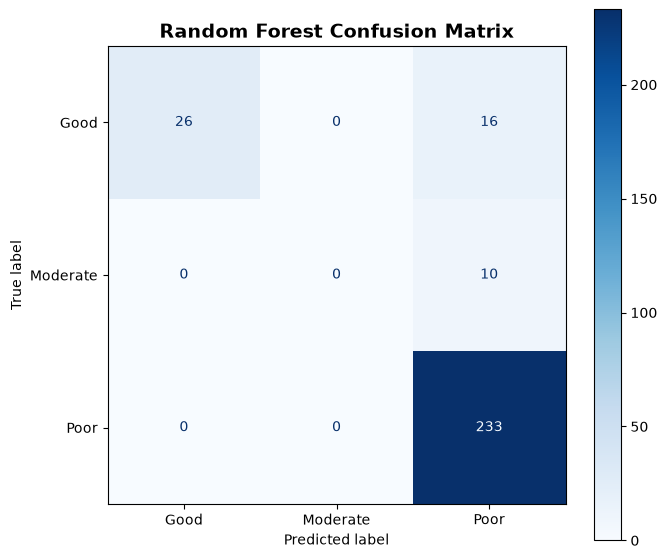

In [11]:
# --- 9. Confusion Matrix ---
labels = ['Good', 'Moderate', 'Poor']
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f'Actual {l}' for l in labels], columns=[f'Pred {l}' for l in labels])

print('Confusion Matrix Table:')
print(cm_df)

# Visualizing Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## 10. Save Model & Scaler Artifacts
Save the trained Random Forest model and feature scaler to `models/` directory for production deployment.

In [12]:
# --- 10. Save Model and Scaler ---
joblib.dump(model, 'models/random_forest_model.joblib')
joblib.dump(scaler, 'models/random_forest_scaler.joblib')
print('Saved models/random_forest_model.joblib')
print('Saved models/random_forest_scaler.joblib')

Saved models/random_forest_model.joblib
Saved models/random_forest_scaler.joblib
